# XPS Driver Test

This notebook demonstrates the use of the XPSDriver class to compute core ionization energies.

In [1]:
import veloxchem as vlx
import numpy as np

## Setup molecule and basis

In [2]:
# Create molecule from SMILES
molecule = vlx.Molecule.read_smiles("NCOCS")

# Setup basis set
basis = vlx.MolecularBasis.read(molecule, "def2-svp")
molecule.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Ground state SCF calculation

In [3]:
# Ground state SCF
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

## XPS calculation for Carbon 1s

In [4]:
# Create XPS driver
xps_drv = vlx.XPSDriver()

# Compute core ionization energies for Carbon
xps_results = xps_drv.compute(molecule, basis, scf_drv, element='C')

# Print results
xps_drv.print_results(xps_results)

                                                                                                                          
                                                        XPS Driver                                                        
                                                                                                                          
* Info * Computing core ionization energies for element(s): C                                                             
                                                                                                                          
                                                                                                                          
* Info * Processing element: C                                                                                            
* Info * ------------------------------------------------------------                                                     
* Info * Found 2

## Plot XPS spectrum for Carbon

<Axes: title={'center': 'XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>

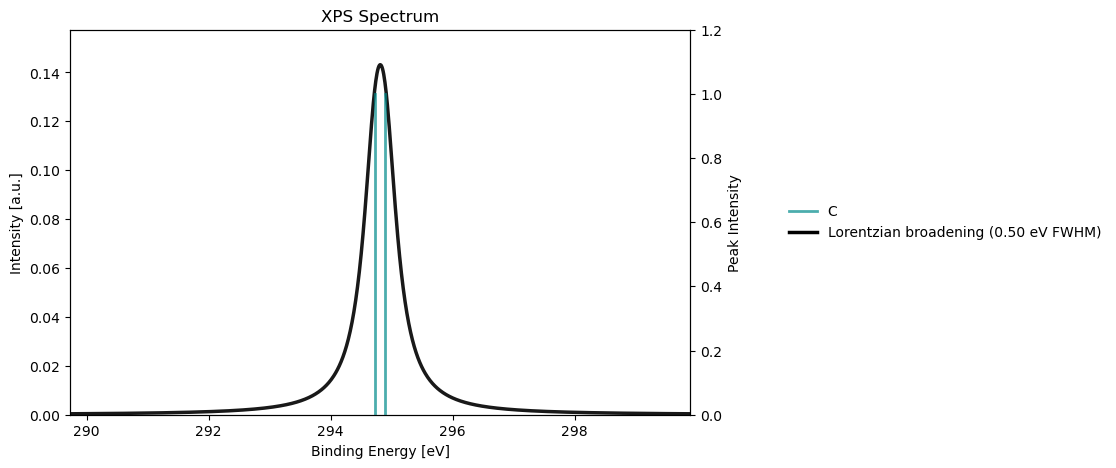

In [5]:

xps_drv.plot_spectrum(xps_results, broadening_type='lorentzian', broadening_value=0.5)


## NEW: Compute multiple elements at once

In [6]:
# Compute XPS for multiple elements at once
xps_multi = xps_drv.compute(molecule, basis, scf_drv, elements=['C', 'O', 'N', 'S'])

# Print results
xps_drv.print_results(xps_multi)

                                                                                                                          
                                                        XPS Driver                                                        
                                                                                                                          
* Info * Computing core ionization energies for element(s): C, O, N, S                                                    
                                                                                                                          
                                                                                                                          
* Info * Processing element: C                                                                                            
* Info * ------------------------------------------------------------                                                     
* Info * Found 2

## Combined plot with CPK colors

array([<Axes: title={'center': 'C 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>,
       <Axes: title={'center': 'O 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>,
       <Axes: title={'center': 'N 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>,
       <Axes: title={'center': 'S 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>],
      dtype=object)

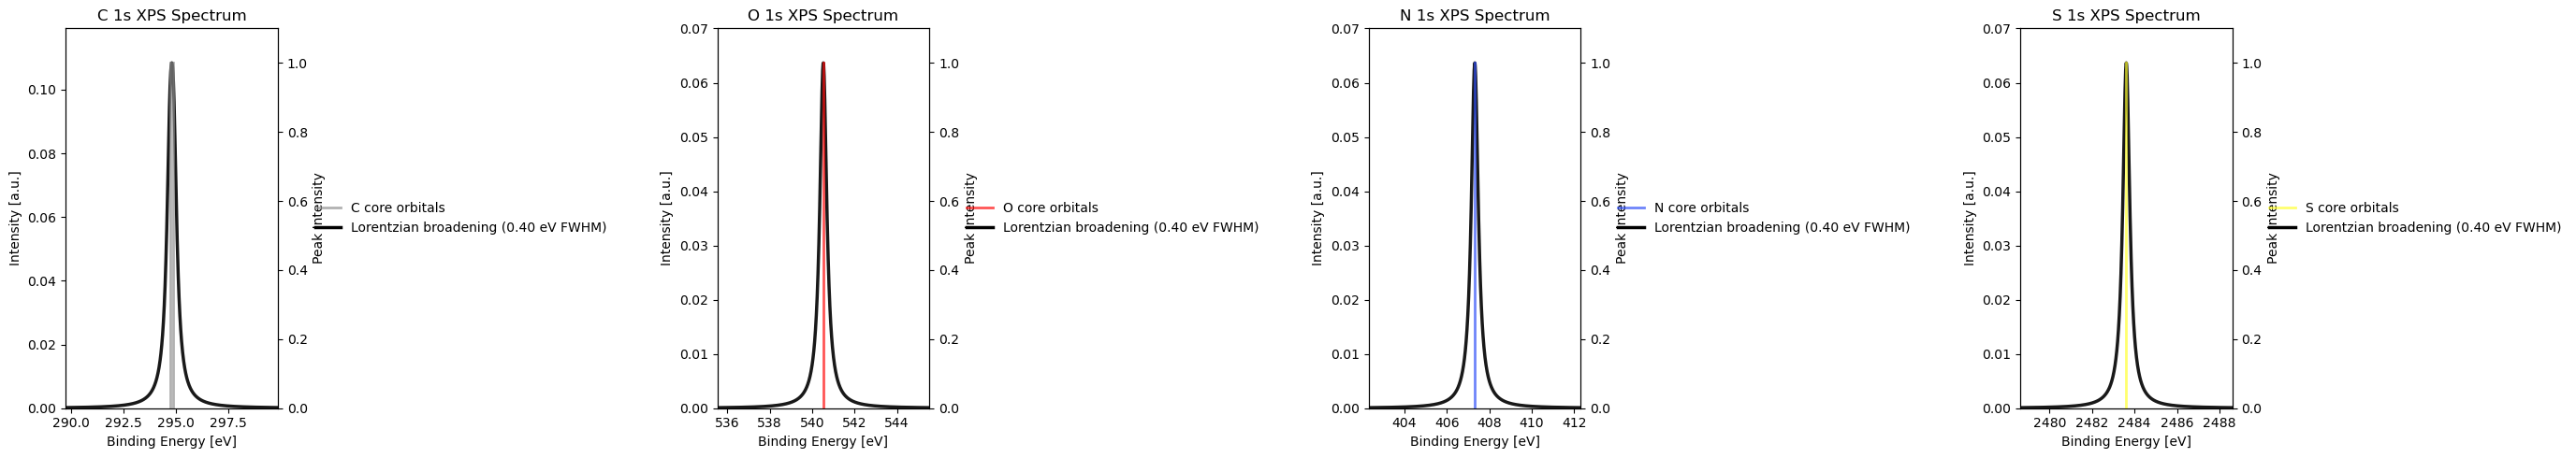

In [7]:
# Plot all elements on the same spectrum with CPK coloring
# C=gray, O=red
xps_drv.plot_spectrum(xps_multi, separate_plots=True, colors='cpk', broadening_value=0.4)


## Separate plots for each element

<Axes: title={'center': 'XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>

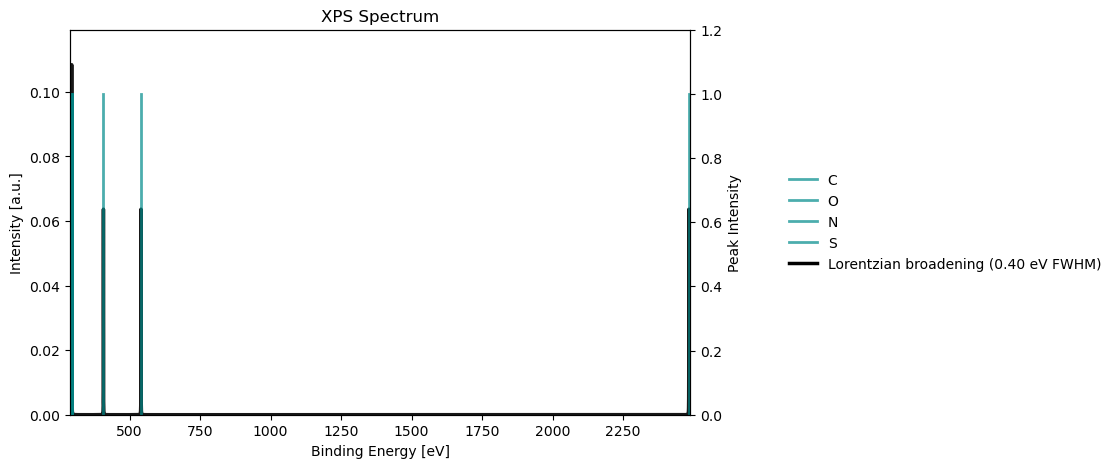

In [8]:
# Plot each element in a separate subplot with CPK colors
xps_drv.plot_spectrum(xps_multi, separate_plots=False, broadening_value=0.4)


## Combined plot with VeloxChem default color

<Axes: title={'center': 'XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>

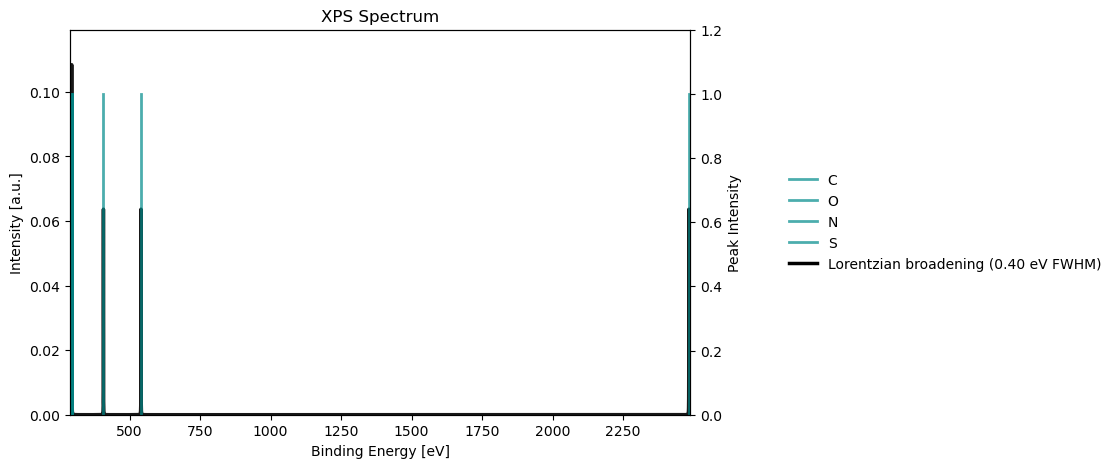

In [9]:
# Plot with VeloxChem default color (darkcyan)
xps_drv.plot_spectrum(xps_multi, separate_plots=False, broadening_value=0.4)


array([<Axes: title={'center': 'C 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>,
       <Axes: title={'center': 'O 1s XPS Spectrum'}, xlabel='Binding Energy [eV]', ylabel='Intensity [a.u.]'>],
      dtype=object)

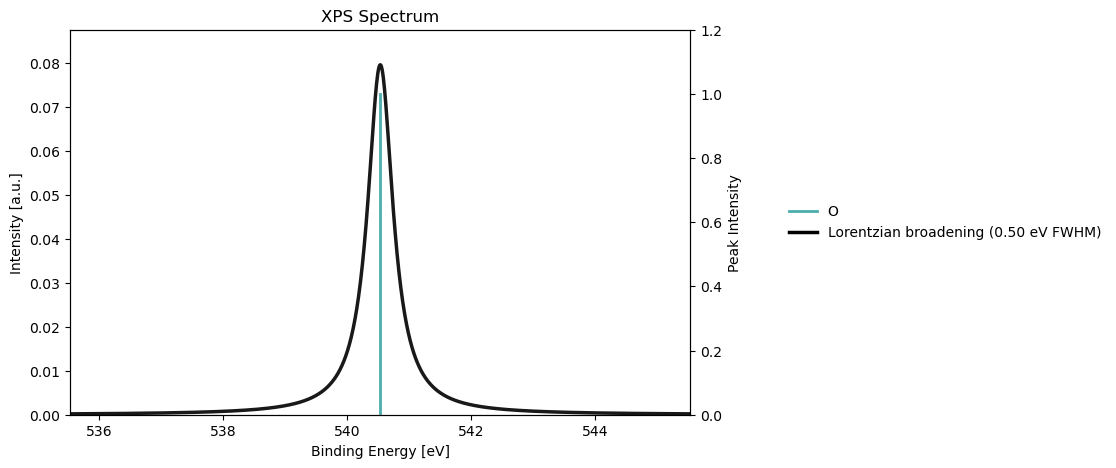

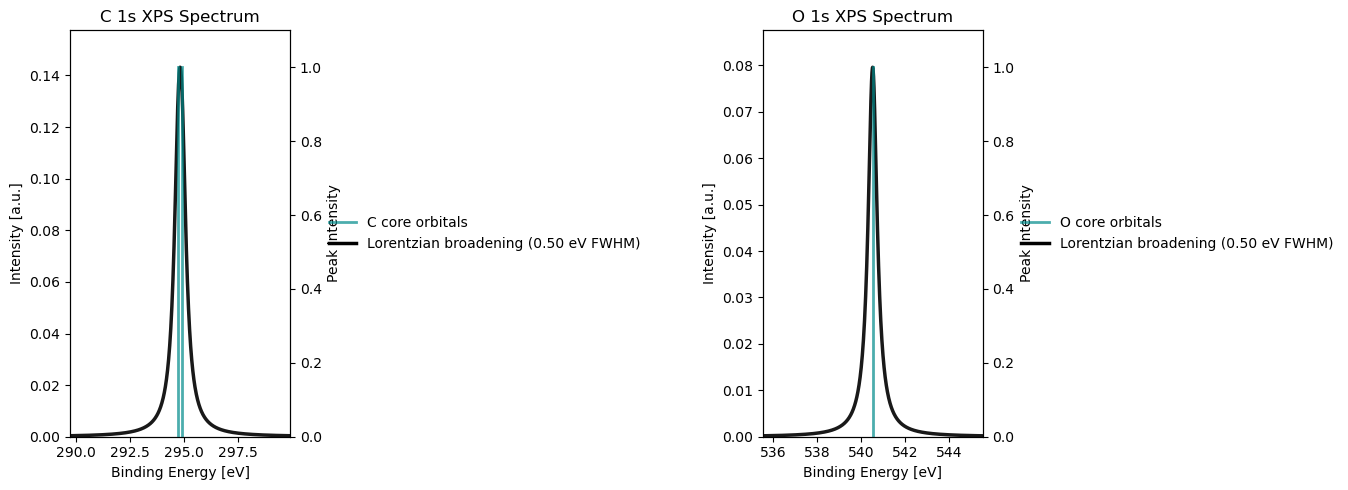

In [12]:
# Plot only Oxygen
xps_drv.plot_spectrum(xps_multi, plot_elements='O')  # Can use string for single element

# Plot specific subset
xps_drv.plot_spectrum(xps_multi, plot_elements=['C', 'O'], separate_plots=True)
